In [1]:
from metab_processing.metab_travlr_config import PROJECT_DATA_DIR, DATA_DIR as METAB_DATA_DIR

XENIUM_DATA_DIR = PROJECT_DATA_DIR
DATASET_NAME = 'Human_Lung'
DATA_DIR = f'{XENIUM_DATA_DIR}/{DATASET_NAME}'

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

In [3]:
adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
adata

AnnData object with n_obs × n_vars = 278328 × 5001
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', '_scvi_batch', '_scvi_labels', 'leiden_scVI_res_0.5', 'leiden_scVI_res_0.75', 'leiden_scVI_res_0.65', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.25', 'leiden_scVI_res_1.5', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.05', 'leiden_scVI_res_2.5', 'leiden_scVI_res_2', 'leiden_scVI_res_1', 'cd8', 'cd4', 't_cell', 'Tier1', 'Tier2', 'Tier3', 'Cytotoxic_CD8_score', 'Exhausted_CD8_score', 'Treg_score', 'sub_cluster_0-10-18-22-9_res_1', 'sub_cluster_0-10-18-22-9_res_0.75', 'sub_cluster_0-10-18-22-9_res_0.5', 'sub_cluster_0-10-18-22-9_res_0.37', 'sub_cluster_0-10-18-22-9_res_0.25', 'sub_cluster_0-10-18-22-9_res_0.15', 'sub_cluster_0-10-18-22-9_res_0.1', 'sub_cluster_0-10-

/tmp/ipykernel_225393/12019399.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='leiden_scVI_res_0.5');


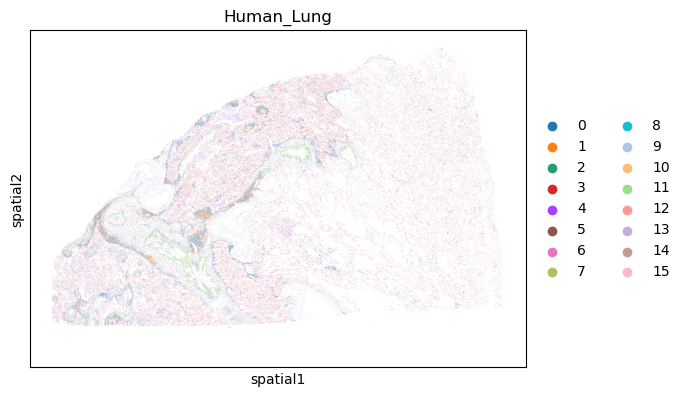

In [4]:
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='leiden_scVI_res_0.5');

In [5]:
# Make sure counts layer exists
if 'counts' not in adata.layers:
    adata.layers['counts'] = adata.X.copy()

# Build log_norm layer from counts if it doesn't exist
if 'log_norm' not in adata.layers:
    adata.X = adata.layers['counts'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.layers['log_norm'] = adata.X.copy()
    # Restore raw counts to X
    adata.X = adata.layers['counts'].copy()

print("Layers available:", list(adata.layers.keys()))
print("X max (should be large if raw counts):", adata.X.max())
print("log_norm max (should be small, ~log scale):", adata.layers['log_norm'].max())

Layers available: ['counts', 'log_norm']
X max (should be large if raw counts): 261.0
log_norm max (should be small, ~log scale): 9.210441


In [6]:
# resolutions = [2.5, 2, 1.5, 1, 0.75, 0.65, 0.5, 0.375, 0.25, 0.1, 0.05]
resolutions = [2.5, 2, 1.5, 1, 0.75, 0.65, 0.5]
def res_label(res):
    return f'leiden_scVI_res_{res}'
res_labels = [res_label(res) for res in resolutions]

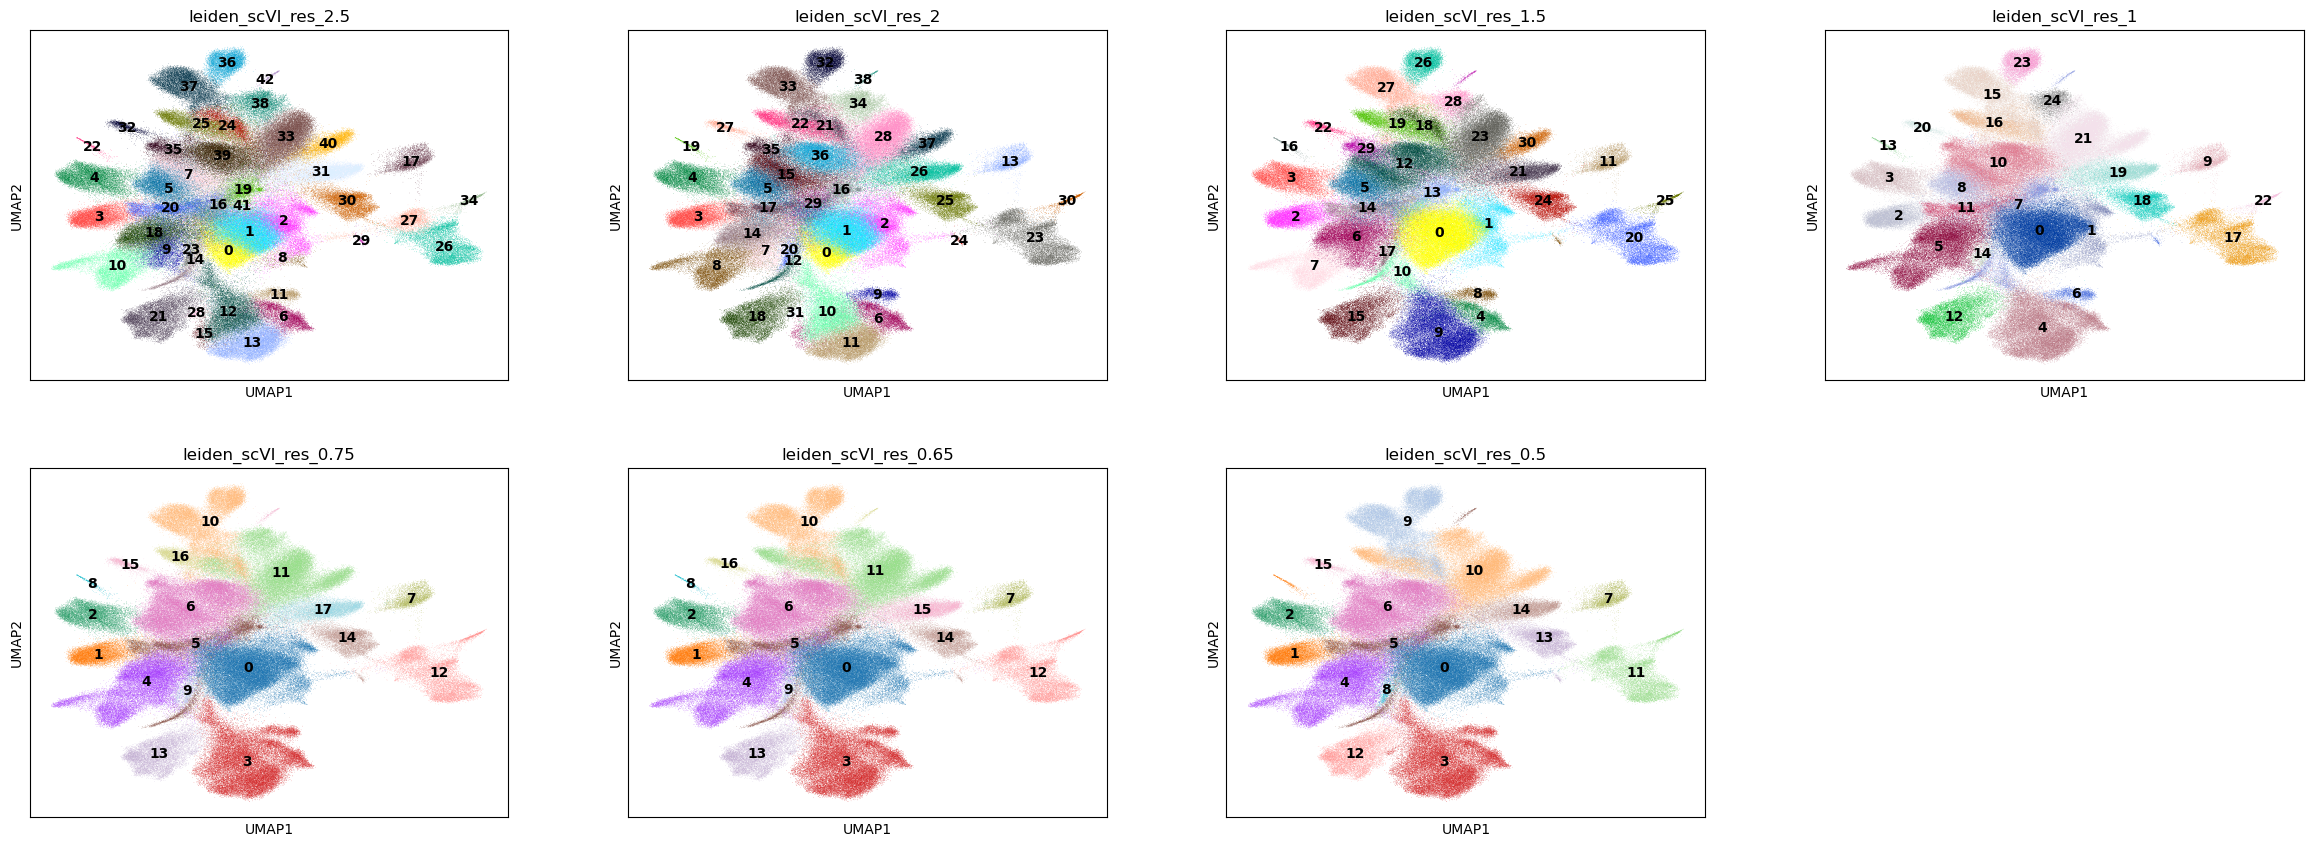

In [7]:
sc.pl.umap(adata, color=res_labels, legend_loc="on data")


RESOLUTION: leiden_scVI_res_2.5


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['CTLA4', 'CD3E', 'FOXP3', 'TIGIT', 'CXCR4', 'IL2RG', 'CD2', 'CCR4', 'BATF', 'ITGAL', 'GBP5', 'CD4', 'SEPTIN6', 'EEF1G', 'CD247']
Cluster 1: ['CXCR4', 'CD3E', 'EEF1G', 'CD44', 'IKZF1', 'CD2', 'HNRNPA1L2', 'ITGAL', 'SEPTIN9', 'CD96', 'IL2RG', 'ACAP1', 'ETS1', 'CDKN1B', 'SEMA4D']
Cluster 2: ['CXCR4', 'CD8A', 'CD3E', 'ITGAL', 'CST7', 'GZMA', 'CD2', 'KLRK1', 'IKZF3', 'ETS1', 'CD247', 'IL2RG', 'CD96', 'GZMH', 'GZMB']
Cluster 3: ['MS4A1', 'CXCR4', 'EEF1G', 'TNFRSF13C', 'CD19', 'CD79A', 'BANK1', 'SMAP2', 'POU2AF1', 'CD22', 'BLK', 'CIITA', 'SP140', 'HNRNPH1', 'NCF1']
Cluster 4: ['XBP1', 'MZB1', 'TENT5C', 'SLAMF7', 'PIM2', 'POU2AF1', 'DERL3', 'CD79A', 'EEF1G', 'SEL1L', 'CXCR4', 'CD38', 'MAN1A1', 'PDK1', 'CYBA']
Cluster 5: ['COL5A1', 'LTBP2', 'POSTN', 'MMP14', 'NBL1', 'AEBP1', 'CDH11', 'THY1', 'COL4A1', 'COL10A1', 'COL5A2', 'CCDC80', 'SULF1', 'TMEM119', 'FSTL1']
Cluster 6: ['PDIA4', 'CLPTM1L', 'LAPTM4B', 'HHLA2', 'ST14', 'CDH1', 'TMPRSS2', 

/tmp/ipykernel_225393/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225393/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_2.5                                                         
0                               0.246624             0.555618    1.093707   
1                               0.334251             0.266802    0.526288   
2                               0.882345             0.658303    0.385408   
3                              -0.005968            -0.001414    0.091837   
4                              -0.043417            -0.046617    0.026331   
5                              -0.031063            -0.025469    0.141416   
6                              -0.336590            -0.474147   -0.411213   
7                              -0.070397            -0.081141    0.003589   
8                               0.725586             0.776619    0.614309   
9                              -0.091412             0.008368    0.271760   
10        

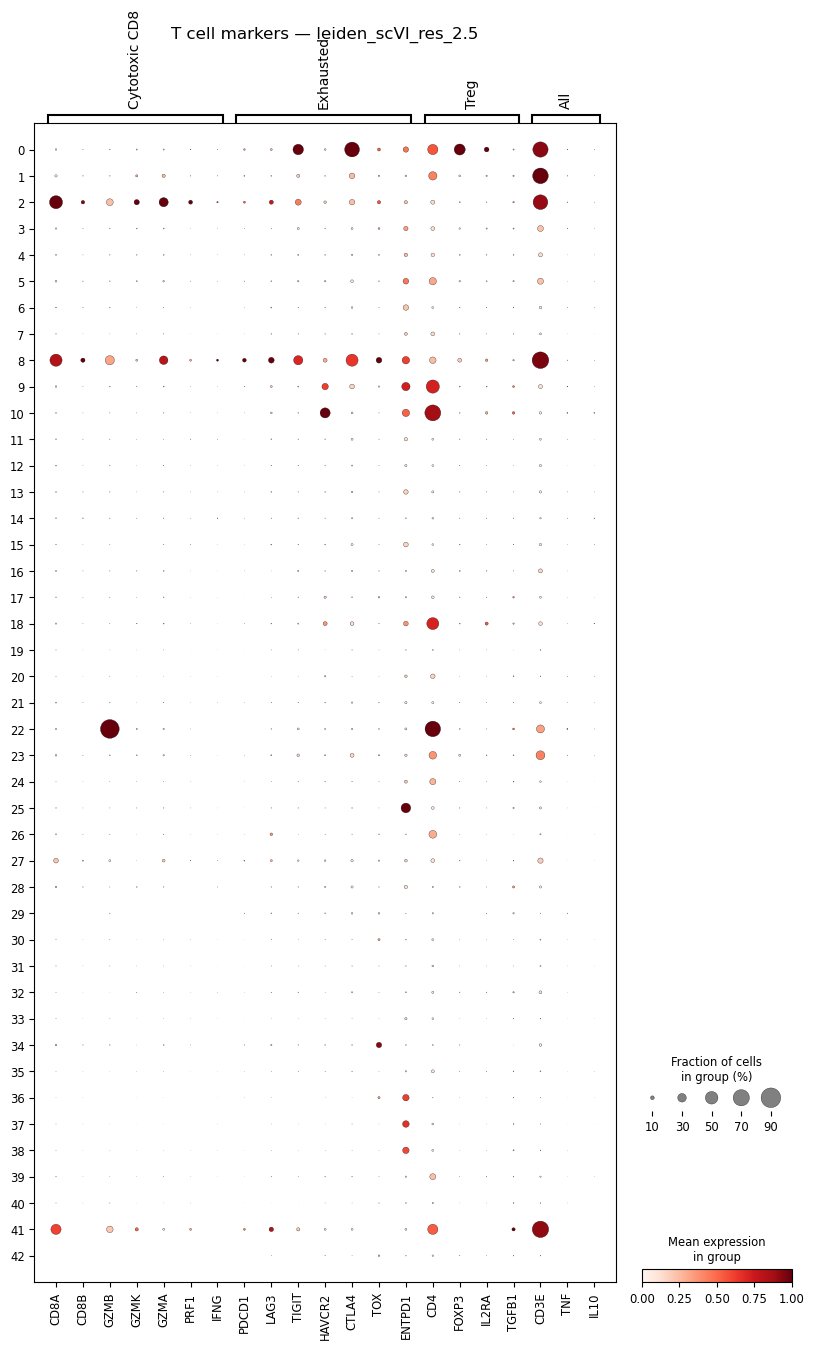


RESOLUTION: leiden_scVI_res_2


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['CTLA4', 'CD3E', 'FOXP3', 'TIGIT', 'CXCR4', 'IL2RG', 'BATF', 'CD2', 'CCR4', 'GBP5', 'ITGAL', 'CD4', 'SEPTIN6', 'CD247', 'TNFRSF1B']
Cluster 1: ['CXCR4', 'CD3E', 'EEF1G', 'CD44', 'IKZF1', 'CD2', 'ITGAL', 'HNRNPA1L2', 'SEPTIN9', 'IL2RG', 'CD96', 'ACAP1', 'ETS1', 'CCR4', 'SEPTIN6']
Cluster 2: ['CD8A', 'CD3E', 'CXCR4', 'ITGAL', 'GZMA', 'CST7', 'CD2', 'KLRK1', 'IKZF3', 'GZMB', 'CD247', 'ETS1', 'IL2RG', 'CD96', 'FYN']
Cluster 3: ['MS4A1', 'CXCR4', 'EEF1G', 'TNFRSF13C', 'CD19', 'CD79A', 'BANK1', 'SMAP2', 'POU2AF1', 'CD22', 'BLK', 'CIITA', 'SP140', 'HNRNPH1', 'SCIMP']
Cluster 4: ['XBP1', 'MZB1', 'TENT5C', 'SLAMF7', 'PIM2', 'POU2AF1', 'DERL3', 'CD79A', 'EEF1G', 'SEL1L', 'CXCR4', 'CD38', 'MAN1A1', 'PDK1', 'CYBA']
Cluster 5: ['COL5A1', 'LTBP2', 'POSTN', 'MMP14', 'NBL1', 'AEBP1', 'CDH11', 'THY1', 'COL4A1', 'COL10A1', 'COL5A2', 'CCDC80', 'SULF1', 'TMEM119', 'FSTL1']
Cluster 6: ['PDIA4', 'CLPTM1L', 'LAPTM4B', 'HHLA2', 'ST14', 'EPDR1', 'EPCAM',

/tmp/ipykernel_225393/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225393/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                   Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_2                                                         
0                             0.242926             0.587473    1.177741   
1                             0.341943             0.284121    0.534026   
2                             0.896983             0.690457    0.398050   
3                            -0.006113            -0.000280    0.094203   
4                            -0.043477            -0.046287    0.026239   
5                            -0.025496            -0.018925    0.146075   
6                            -0.344638            -0.480764   -0.420505   
7                            -0.095199             0.003562    0.256907   
8                            -0.166346            -0.102321    0.194216   
9                            -0.310032            -0.443090   -0.377074   
10                           -0.18

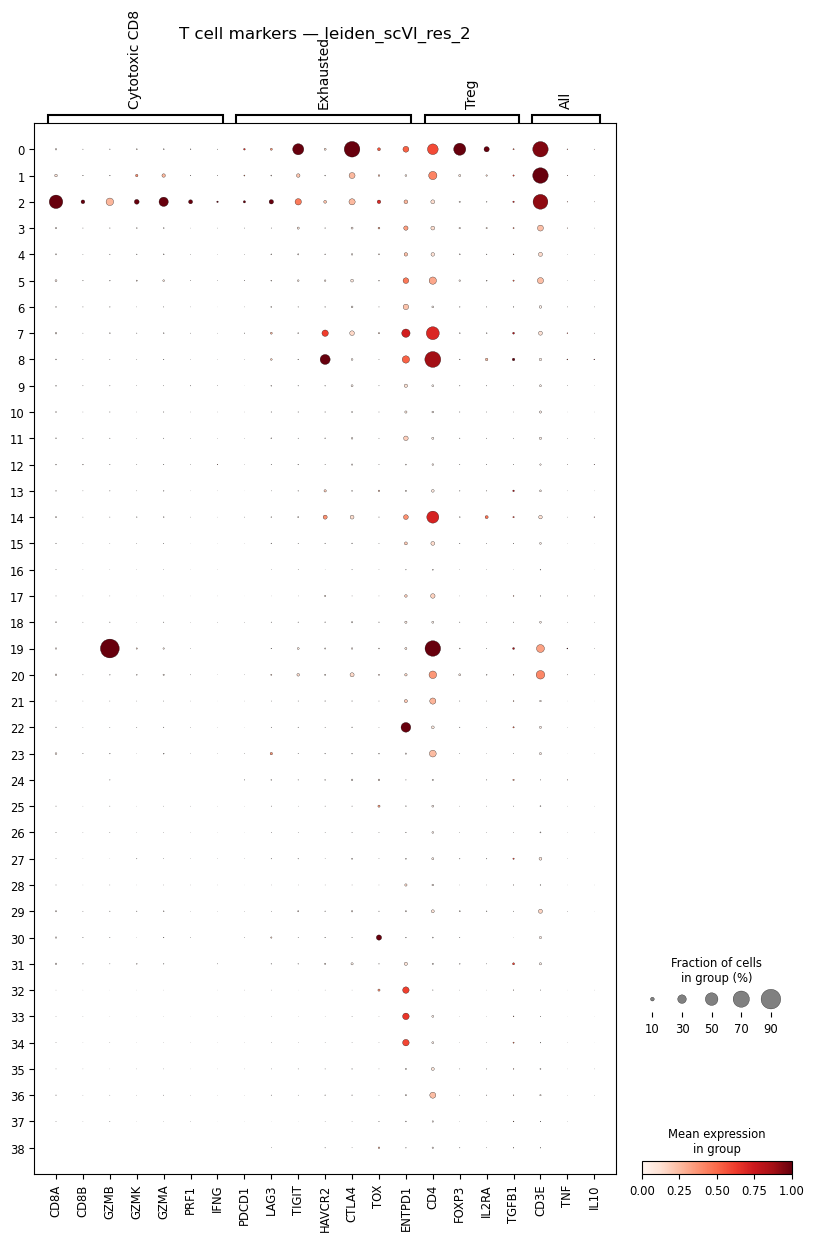


RESOLUTION: leiden_scVI_res_1.5


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['CXCR4', 'CD3E', 'EEF1G', 'CD44', 'CD2', 'ITGAL', 'IKZF1', 'IL2RG', 'CTLA4', 'CCR4', 'HNRNPA1L2', 'SEPTIN6', 'ETS1', 'ITGA4', 'SEPTIN9']
Cluster 1: ['CD8A', 'CD3E', 'CXCR4', 'ITGAL', 'GZMA', 'GZMB', 'KLRK1', 'CD2', 'CST7', 'CD247', 'IL2RG', 'IKZF3', 'CD96', 'MSN', 'ETS1']
Cluster 2: ['MS4A1', 'CXCR4', 'EEF1G', 'TNFRSF13C', 'CD19', 'CD79A', 'BANK1', 'SMAP2', 'POU2AF1', 'CD22', 'BLK', 'CIITA', 'SP140', 'HNRNPH1', 'SCIMP']
Cluster 3: ['XBP1', 'MZB1', 'TENT5C', 'SLAMF7', 'PIM2', 'POU2AF1', 'DERL3', 'CD79A', 'EEF1G', 'SEL1L', 'CXCR4', 'CD38', 'MAN1A1', 'PDK1', 'CYBA']
Cluster 4: ['PDIA4', 'CLPTM1L', 'LAPTM4B', 'HHLA2', 'ST14', 'CDH1', 'TMPRSS2', 'CP', 'EPCAM', 'DDR1', 'FOLR1', 'EPDR1', 'TREM1', 'HS6ST2', 'MX1']
Cluster 5: ['COL5A1', 'LTBP2', 'POSTN', 'MMP14', 'NBL1', 'AEBP1', 'CDH11', 'THY1', 'COL4A1', 'COL10A1', 'COL5A2', 'SULF1', 'CCDC80', 'TMEM119', 'FSTL1']
Cluster 6: ['CD14', 'FCGR2A', 'SLCO2B1', 'MRC1', 'CTSC', 'F13A1', 'CD4', '

/tmp/ipykernel_225393/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225393/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_1.5                                                         
0                               0.363009             0.373694    0.653700   
1                               0.890296             0.700147    0.392099   
2                              -0.008180            -0.003606    0.089883   
3                              -0.044626            -0.047117    0.025682   
4                              -0.335282            -0.472353   -0.409272   
5                              -0.052872            -0.038468    0.123193   
6                              -0.060908             0.002079    0.291177   
7                              -0.167058            -0.102230    0.194470   
8                              -0.309370            -0.441307   -0.377125   
9                              -0.287904            -0.410720   -0.359651   
10        

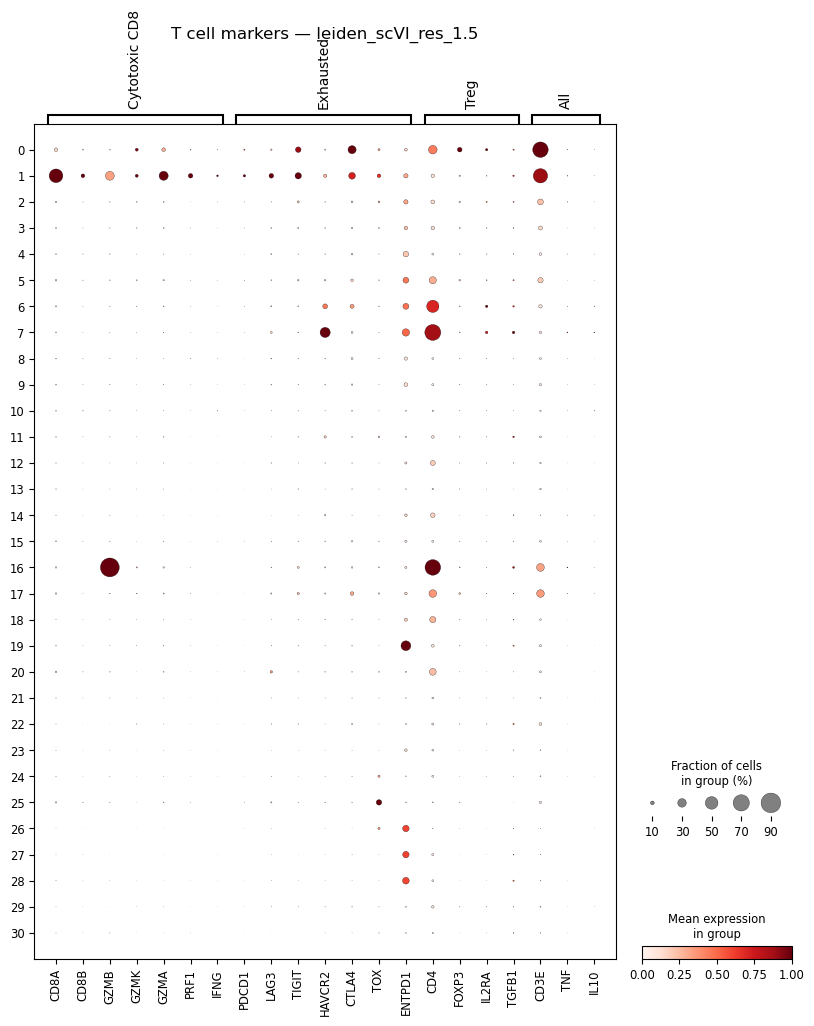


RESOLUTION: leiden_scVI_res_1


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['CXCR4', 'CD3E', 'EEF1G', 'CD44', 'CD2', 'ITGAL', 'IKZF1', 'IL2RG', 'CTLA4', 'CCR4', 'HNRNPA1L2', 'ETS1', 'ITGA4', 'SEPTIN6', 'SEPTIN9']
Cluster 1: ['CD8A', 'CD3E', 'GZMB', 'ITGAL', 'CXCR4', 'GZMA', 'KLRK1', 'CD247', 'CD2', 'MSN', 'IL2RG', 'CD96', 'ETS1', 'IKZF3', 'CST7']
Cluster 2: ['EEF1G', 'MS4A1', 'CXCR4', 'TNFRSF13C', 'CD19', 'CD79A', 'BANK1', 'POU2AF1', 'SMAP2', 'CD22', 'BLK', 'SP140', 'CIITA', 'NCF1', 'SCIMP']
Cluster 3: ['XBP1', 'MZB1', 'TENT5C', 'SLAMF7', 'PIM2', 'POU2AF1', 'DERL3', 'CD79A', 'EEF1G', 'SEL1L', 'CXCR4', 'CD38', 'MAN1A1', 'PDK1', 'CYBA']
Cluster 4: ['CLPTM1L', 'EPCAM', 'LAPTM4B', 'PDIA4', 'HHLA2', 'EPDR1', 'CDH1', 'NKX2-1', 'VSTM2L', 'MUC1', 'CTSH', 'TMPRSS2', 'DDR1', 'FOLR1', 'HPGD']
Cluster 5: ['CD68', 'FCGR2A', 'MRC1', 'CD14', 'SLCO2B1', 'MSR1', 'GRN', 'CTSC', 'ITGB2', 'PLAUR', 'CYBB', 'C5AR1', 'CD4', 'SGK1', 'CTSL']
Cluster 6: ['LPCAT1', 'STEAP4', 'HHLA2', 'CDH1', 'LAPTM4B', 'CLPTM1L', 'EPCAM', 'FOLR1',

/tmp/ipykernel_225393/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225393/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                   Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_1                                                         
0                             0.392753             0.384951    0.625223   
1                             0.892087             0.727665    0.401189   
2                            -0.009633            -0.007157    0.077675   
3                            -0.047965            -0.050009    0.020667   
4                            -0.294393            -0.418932   -0.365897   
5                            -0.106586            -0.043329    0.253375   
6                            -0.309850            -0.442041   -0.377545   
7                            -0.020393            -0.023413   -0.008143   
8                            -0.075982            -0.056187    0.102809   
9                            -0.080765            -0.077224   -0.045188   
10                           -0.09

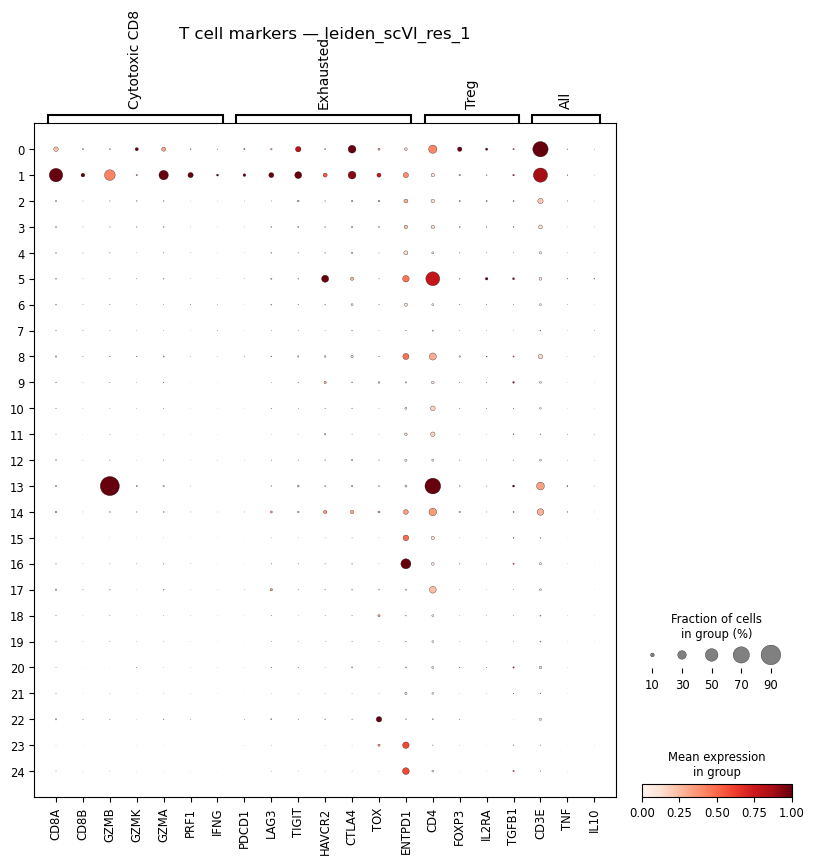


RESOLUTION: leiden_scVI_res_0.75

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['CXCR4', 'CD3E', 'EEF1G', 'CD2', 'ITGAL', 'CD44', 'IL2RG', 'IKZF1', 'CTLA4', 'ETS1', 'CD247', 'CD96', 'HNRNPA1L2', 'SEPTIN9', 'ITGA4']
Cluster 1: ['MS4A1', 'CXCR4', 'EEF1G', 'TNFRSF13C', 'CD19', 'CD79A', 'BANK1', 'SMAP2', 'POU2AF1', 'CD22', 'CIITA', 'BLK', 'SP140', 'HNRNPH1', 'NCF1']
Cluster 2: ['XBP1', 'MZB1', 'TENT5C', 'SLAMF7', 'PIM2', 'POU2AF1', 'DERL3', 'CD79A', 'EEF1G', 'SEL1L', 'CXCR4', 'CD38', 'MAN1A1', 'PDK1', 'CYBA']
Cluster 3: ['CLPTM1L', 'EPCAM', 'PDIA4', 'LAPTM4B', 'HHLA2', 'CDH1', 'EPDR1', 'NKX2-1', 'VSTM2L', 'MUC1', 'TMPRSS2', 'FOLR1', 'CTSH', 'DDR1', 'CTTN']
Cluster 4: ['CD68', 'FCGR2A', 'MRC1', 'CD14', 'SLCO2B1', 'MSR1', 'GRN', 'CTSC', 'CYBB', 'ITGB2', 'PLAUR', 'C5AR1', 'CD4', 'SGK1', 'CTSL']
Cluster 5: ['SOX2-OT', 'MXD1', 'LILRA5', 'FPR1', 'C5AR1', 'ITGAX', 'CSF3R', 'BCL2A1', 'PLAUR', 'CD300E', 'FPR2', 'CFP', 'FGR', 'NLRP3', 'HCK']
Cluster 6: ['LTBP2', 'NBL1', 'CCN1', 'COL5A1', 

/tmp/ipykernel_225393/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225393/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                      Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.75                                                         
0                                0.455379             0.427106    0.590947   
1                               -0.013181            -0.008459    0.083127   
2                               -0.049386            -0.051044    0.018277   
3                               -0.283539            -0.403400   -0.350763   
4                               -0.102521            -0.041538    0.244238   
5                               -0.034647            -0.032749    0.006313   
6                               -0.095244            -0.109210    0.001852   
7                               -0.081450            -0.078299   -0.047495   
8                                0.419469             0.256486    0.319066   
9                               -0.012907             0.042651    0.168523  

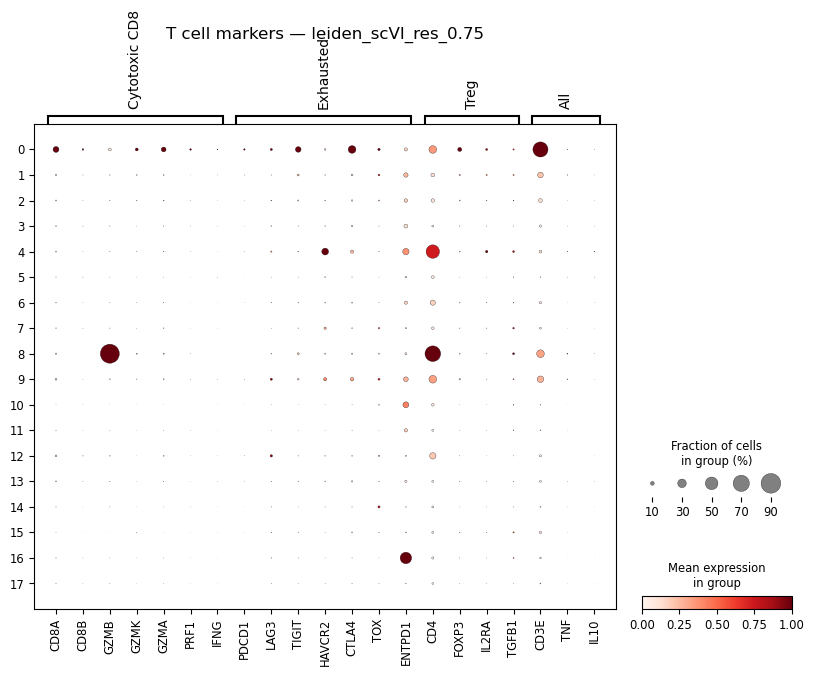


RESOLUTION: leiden_scVI_res_0.65

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['CXCR4', 'CD3E', 'EEF1G', 'CD2', 'ITGAL', 'CD44', 'IL2RG', 'IKZF1', 'CTLA4', 'ETS1', 'CD247', 'CD96', 'HNRNPA1L2', 'SEPTIN9', 'ITGA4']
Cluster 1: ['MS4A1', 'CXCR4', 'EEF1G', 'TNFRSF13C', 'CD19', 'CD79A', 'BANK1', 'SMAP2', 'POU2AF1', 'CD22', 'CIITA', 'BLK', 'SP140', 'HNRNPH1', 'NCF1']
Cluster 2: ['XBP1', 'MZB1', 'TENT5C', 'SLAMF7', 'PIM2', 'POU2AF1', 'DERL3', 'CD79A', 'EEF1G', 'SEL1L', 'CXCR4', 'CD38', 'MAN1A1', 'PDK1', 'CYBA']
Cluster 3: ['CLPTM1L', 'EPCAM', 'PDIA4', 'LAPTM4B', 'HHLA2', 'CDH1', 'EPDR1', 'NKX2-1', 'VSTM2L', 'MUC1', 'TMPRSS2', 'FOLR1', 'CTSH', 'DDR1', 'CTTN']
Cluster 4: ['CD68', 'FCGR2A', 'MRC1', 'CD14', 'SLCO2B1', 'MSR1', 'GRN', 'CTSC', 'ITGB2', 'CYBB', 'PLAUR', 'C5AR1', 'CD4', 'SGK1', 'CTSL']
Cluster 5: ['SOX2-OT', 'MXD1', 'LILRA5', 'FPR1', 'CSF3R', 'ITGAX', 'C5AR1', 'BCL2A1', 'PLAUR', 'CD300E', 'FPR2', 'CFP', 'FGR', 'HCK', 'NLRP3']
Cluster 6: ['LTBP2', 'NBL1', 'CCN1', 'COL5A1', 

/tmp/ipykernel_225393/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225393/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                      Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.65                                                         
0                                0.454049             0.425826    0.589824   
1                               -0.013070            -0.007919    0.084560   
2                               -0.052241            -0.053297    0.016003   
3                               -0.283589            -0.403339   -0.350912   
4                               -0.103666            -0.041713    0.238368   
5                               -0.034500            -0.032764    0.005220   
6                               -0.096287            -0.110132    0.001248   
7                               -0.081938            -0.078413   -0.047513   
8                                0.418798             0.254631    0.316791   
9                                0.012575             0.024255    0.175858  

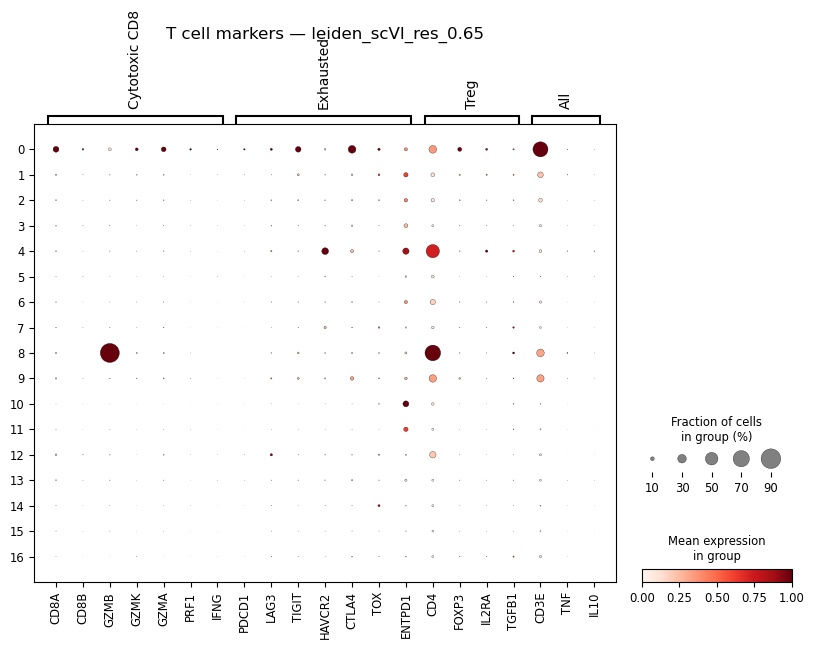


RESOLUTION: leiden_scVI_res_0.5

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['CXCR4', 'CD3E', 'EEF1G', 'CD2', 'ITGAL', 'CD44', 'IL2RG', 'IKZF1', 'CTLA4', 'ETS1', 'CD247', 'CD96', 'HNRNPA1L2', 'ITGA4', 'SEPTIN9']
Cluster 1: ['CXCR4', 'MS4A1', 'EEF1G', 'TNFRSF13C', 'CD19', 'CD79A', 'BANK1', 'SMAP2', 'POU2AF1', 'CD22', 'CIITA', 'BLK', 'SP140', 'HNRNPH1', 'NCF1']
Cluster 2: ['XBP1', 'MZB1', 'TENT5C', 'SLAMF7', 'PIM2', 'POU2AF1', 'DERL3', 'CD79A', 'EEF1G', 'SEL1L', 'CD38', 'CXCR4', 'MAN1A1', 'PDK1', 'CYBA']
Cluster 3: ['CLPTM1L', 'EPCAM', 'PDIA4', 'LAPTM4B', 'CDH1', 'HHLA2', 'NKX2-1', 'EPDR1', 'VSTM2L', 'MUC1', 'TMPRSS2', 'CTSH', 'FOLR1', 'DDR1', 'CTTN']
Cluster 4: ['CD68', 'FCGR2A', 'CD14', 'MRC1', 'SLCO2B1', 'MSR1', 'GRN', 'CTSC', 'ITGB2', 'CYBB', 'PLAUR', 'C5AR1', 'CD4', 'SGK1', 'CTSL']
Cluster 5: ['SOX2-OT', 'MXD1', 'LILRA5', 'FPR1', 'CSF3R', 'ITGAX', 'C5AR1', 'BCL2A1', 'CD300E', 'PLAUR', 'FPR2', 'CFP', 'FGR', 'HCK', 'NLRP3']
Cluster 6: ['LTBP2', 'NBL1', 'CCN1', 'COL5A1', '

/tmp/ipykernel_225393/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_225393/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.5                                                         
0                               0.452139             0.423981    0.587230   
1                               0.001244             0.000297    0.090925   
2                              -0.053158            -0.054506    0.014362   
3                              -0.284180            -0.404309   -0.351830   
4                              -0.103626            -0.041684    0.239157   
5                              -0.036339            -0.034703    0.003467   
6                              -0.097269            -0.111304   -0.000758   
7                              -0.082254            -0.078615   -0.047366   
8                               0.010895             0.022292    0.173442   
9                              -0.108893            -0.074013    0.004378   
10        

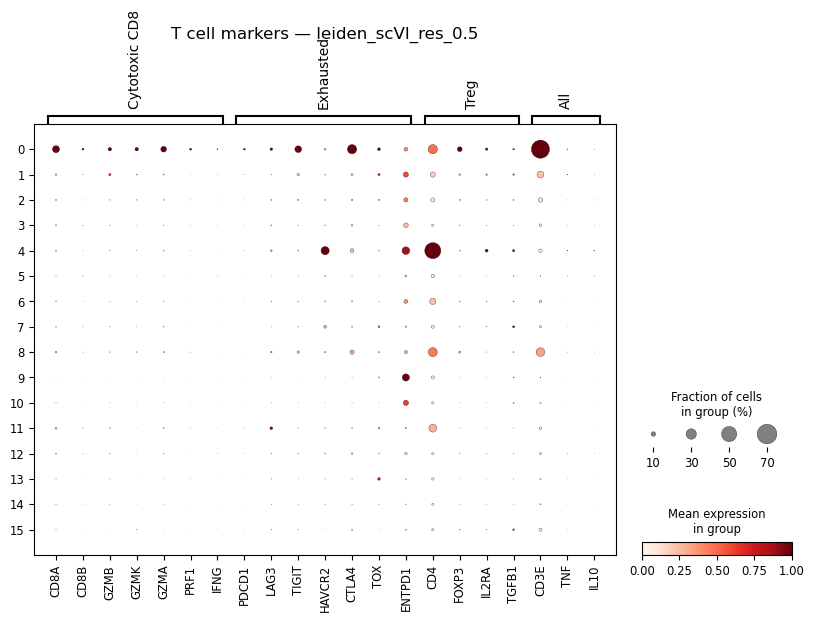

In [8]:
marker_sets = {
    'Cytotoxic_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG', 'TNF'],
    'Exhausted_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'CD3D', 'CD3E', 'FOXP3', 'IL2RA', 'CTLA4', 'IL10', 'TGFB1', 'ENTPD1'],
}

marker_genes_dotplot = {
    'Cytotoxic CD8': ['CD8A', 'CD8B', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG'],
    'Exhausted': ['PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'FOXP3', 'IL2RA', 'TGFB1'],
    'All': ['CD3D', 'CD3E', 'TNF', 'IL10'],
}


def annotate_clusters(adata, groupby_key, n_top_genes=15, de_genes_dict=None):
    print(f"\n{'='*60}")
    print(f"RESOLUTION: {groupby_key}")
    print(f"{'='*60}")
    
    # --- Approach 1: top DE genes per cluster (on log_norm) ---
    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby_key,
        method='wilcoxon',
        layer='log_norm',
        use_raw=False
    )
    result = adata.uns['rank_genes_groups']
    groups = result['names'].dtype.names
    
    # Initialize dictionary for this resolution if provided
    if de_genes_dict is not None:
        de_genes_dict[groupby_key] = {}
    
    print("\n--- Top DE genes per cluster (log_norm) ---")
    for group in groups:
        top_genes = result['names'][group][:n_top_genes]
        print(f"Cluster {group}: {list(top_genes)}")
        # Save DE genes to the dictionary
        if de_genes_dict is not None:
            de_genes_dict[groupby_key][group] = list(top_genes)
    
    # --- Approach 2: marker set scores per cluster (on log_norm) ---
    for name, genes in marker_sets.items():
        genes_present = [g for g in genes if g in adata.var_names]
        sc.tl.score_genes(
            adata,
            gene_list=genes_present,
            score_name=f'{name}_score',
            layer='log_norm'
        )
    
    score_cols = [f'{name}_score' for name in marker_sets.keys()]

    # 1. Calculate the mean scores per cluster
    cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
    # 2. Calculate the cell count per cluster and add it as a new column
    cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()
    print("\n--- Marker set scores and cell counts per cluster (log_norm) ---")
    print(cluster_scores)
    
    # --- Approach 3: dot plot (on log_norm) ---
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes_dotplot.items()
    }
    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=groupby_key,
        layer='log_norm',
        standard_scale='var',
        title=f'T cell markers — {groupby_key}'
    )
    
    return cluster_scores

# Initialize the dictionary and run the loop
de_genes_dict = {}
all_scores = {}
for res_key in res_labels:
    all_scores[res_key] = annotate_clusters(adata, res_key, de_genes_dict=de_genes_dict)

In [9]:
all_scores[res_label(2.5)]

,Cytotoxic_CD8_score,Exhausted_CD8_score,Treg_score,cell_count
leiden_scVI_res_2.5,,,,
0,0.246624,0.555618,1.093707,8915
1,0.334251,0.266802,0.526288,20241
2,0.882345,0.658303,0.385408,11464
3,-0.005968,-0.001414,0.091837,9666
4,-0.043417,-0.046617,0.026331,9471
5,-0.031063,-0.025469,0.141416,11874
6,-0.336590,-0.474147,-0.411213,5259
7,-0.070397,-0.081141,0.003589,10290
8,0.725586,0.776619,0.614309,875


/tmp/ipykernel_225393/3308504833.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='t_cell');


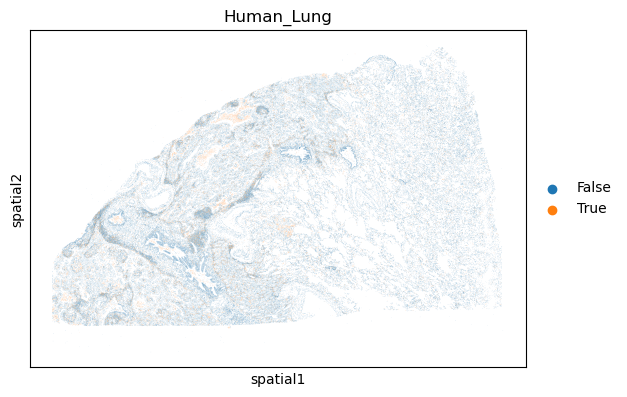

In [10]:
res = 2.5
cd8 = ['2', '8'] #CD8
cd4 = ['0', '9', '10', '18', '22'] #CD4
t_cell_clusts = list(set(cd8 + cd4))
adata.obs['cd8'] = adata.obs[res_label(res)].isin(cd8) 
adata.obs['cd4'] = adata.obs[res_label(res)].isin(cd4)
adata.obs['t_cell'] = adata.obs[res_label(res)].isin(t_cell_clusts) 
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='t_cell');

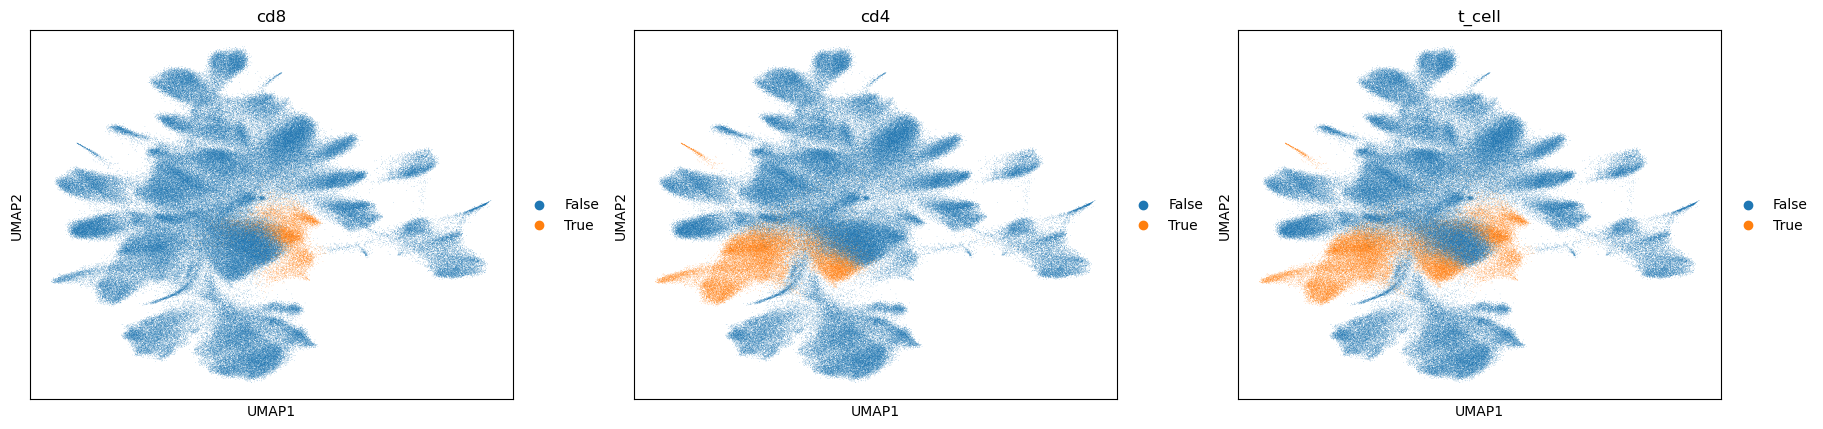

In [11]:
sc.pl.umap(adata, color=['cd8', 'cd4', 't_cell'])

In [12]:
print(f'Not t cell: {sum(~adata.obs['t_cell'])}')
print(f't cell: {sum(adata.obs['t_cell'])}')
print(f'cd8: {sum(adata.obs['cd8'])}')
print(f'cd4: {sum(adata.obs['cd4'])}')

Not t cell: 231605
t cell: 46723
cd8: 12339
cd4: 34384


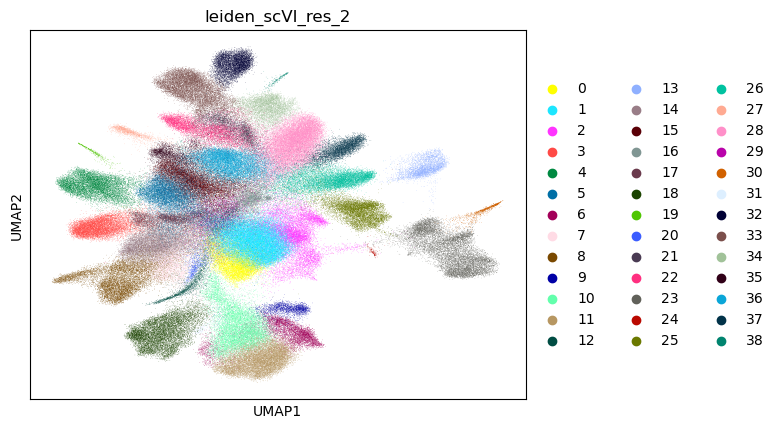

In [13]:
sc.pl.umap(adata, color=[res_label(2)])

In [14]:
def sub_res_label(res, clusters):
    """Order of clusters does not matter"""
    return f'sub_cluster_{"-".join(sorted(clusters))}_res_{res}'

def subcluster(adata, clusters, sub_res, clusters_res_label, de_genes_dict=None):
    print(f'Starting Sub Resolutions {sub_res}')
    new_col_name = sub_res_label(sub_res, clusters)

    # 2. Filter the adata to include only the targeted clusters
    subset_mask = adata.obs[clusters_res_label].isin(clusters)
    adata_sub = adata[subset_mask].copy()

    if new_col_name in adata.obs:
        print(f'{new_col_name} already in adata, skipping')
        # Re-load the existing labels into the subset for DE calculation
        adata_sub.obs[new_col_name] = adata.obs.loc[subset_mask, new_col_name].values
    else:
        # 3. Run the Leiden clustering on the subset
        sc.tl.leiden(adata_sub, resolution=sub_res, key_added=new_col_name, flavor='igraph')
        
        # 4. Initialize the new column in the original adata with "other"
        adata.obs[new_col_name] = "other"
        
        # 5. Map the subset's new cluster results back to the original adata
        adata.obs.loc[subset_mask, new_col_name] = adata_sub.obs[new_col_name].astype(str)
        adata.obs[new_col_name] = adata.obs[new_col_name].astype('category')
    
    # Dot plot base setup
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes_dotplot.items()
    }
    
    # Compute top DE genes for each new subcluster
    sc.tl.rank_genes_groups(
        adata_sub,
        groupby=new_col_name,
        method='wilcoxon',
        layer='log_norm',
        use_raw=False
    )
    result = adata_sub.uns['rank_genes_groups']
    sub_groups = result['names'].dtype.names
    
    # Add top 10 DE genes per subcluster to the dotplot
    for group in sub_groups:
        top_sub_genes = result['names'][group][:10]
        marker_genes_filt[f'Subcluster {group} Top DE'] = [g for g in top_sub_genes if g in adata.var_names]

    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=new_col_name,
        layer='log_norm',
        standard_scale='var',
        title=f'T cell markers & Subcluster DE — {new_col_name}'
    )

    print(f"\nSub-cluster sizes for {new_col_name}:")
    print(adata.obs[new_col_name].value_counts())
    
    return adata

In [15]:
sub_resolutions = [1, 0.75, 0.5, 0.37, 0.25, 0.15, 0.1, 0.05]

In [16]:
print('starting cd4')
for sub_res in sub_resolutions:
    subcluster(adata, cd4, sub_res, clusters_res_label=res_label(res), de_genes_dict=de_genes_dict)
sc.pl.umap(adata, color=[sub_res_label(sub_res, cd4) for sub_res in sub_resolutions])

starting cd4
Starting Sub Resolutions 1
sub_cluster_0-10-18-22-9_res_1 already in adata, skipping


ValueError: Could not calculate statistics for groups other since they only contain one sample.

starting cd8
Starting Sub Resolutions 1


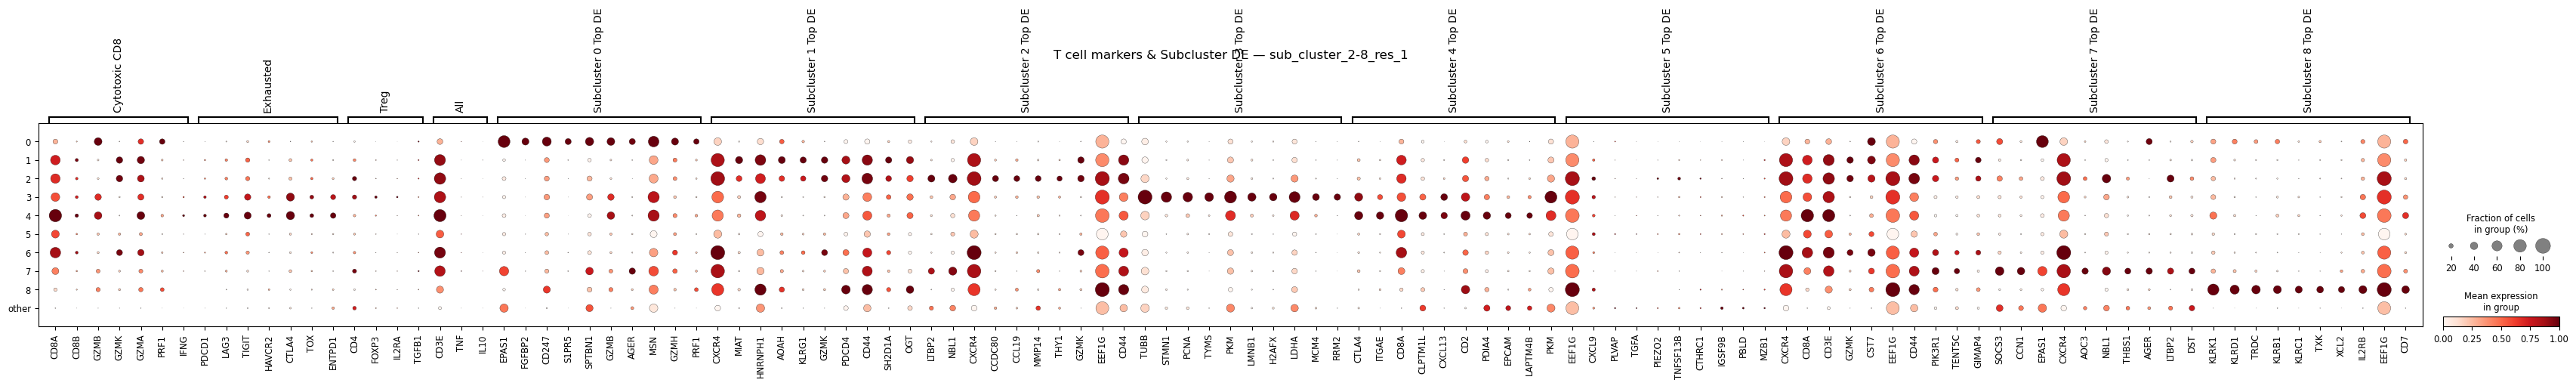


Sub-cluster sizes for sub_cluster_2-8_res_1:
sub_cluster_2-8_res_1
other    265989
4          2375
1          2244
0          2108
7          1620
2          1328
6          1206
3           984
5           383
8            91
Name: count, dtype: int64
Starting Sub Resolutions 0.75


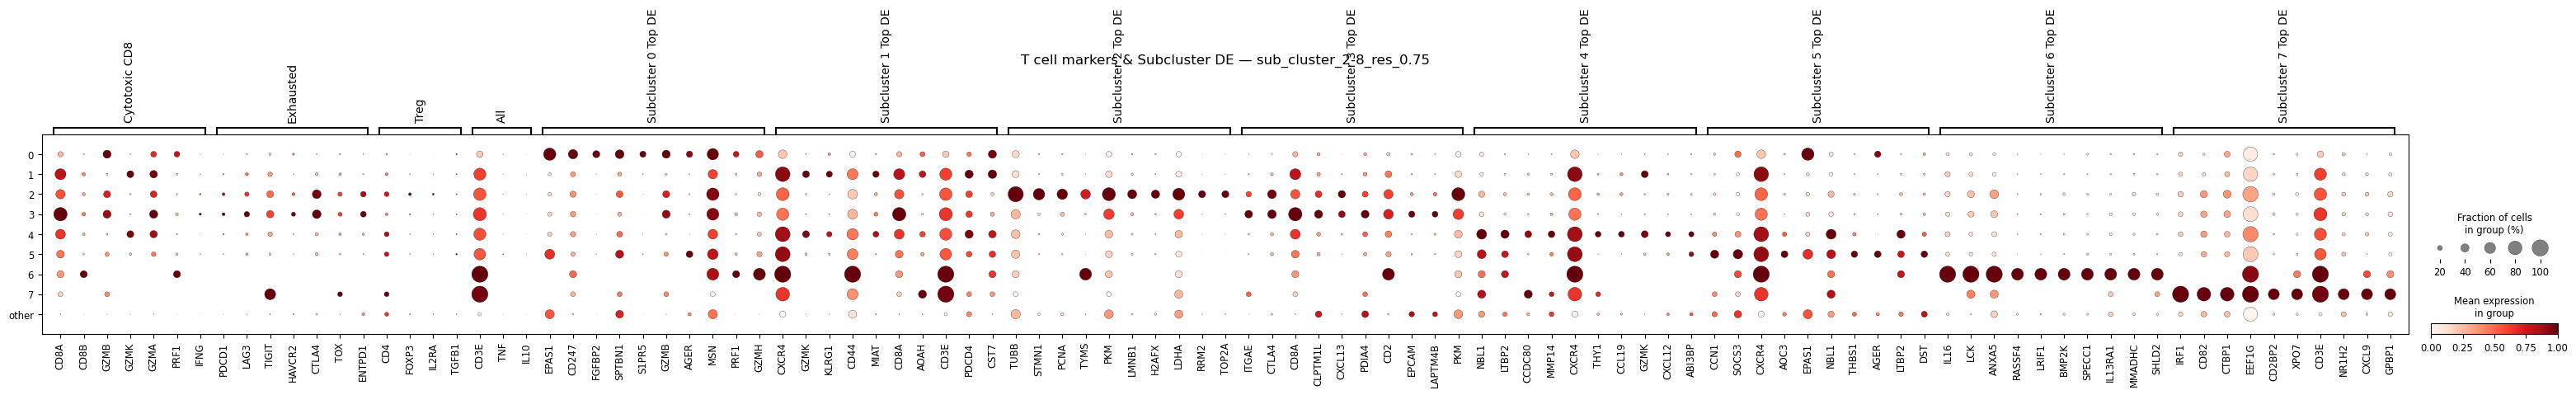


Sub-cluster sizes for sub_cluster_2-8_res_0.75:
sub_cluster_2-8_res_0.75
other    265989
1          3653
3          2594
0          2370
5          1648
4          1110
2           956
7             5
6             3
Name: count, dtype: int64
Starting Sub Resolutions 0.5


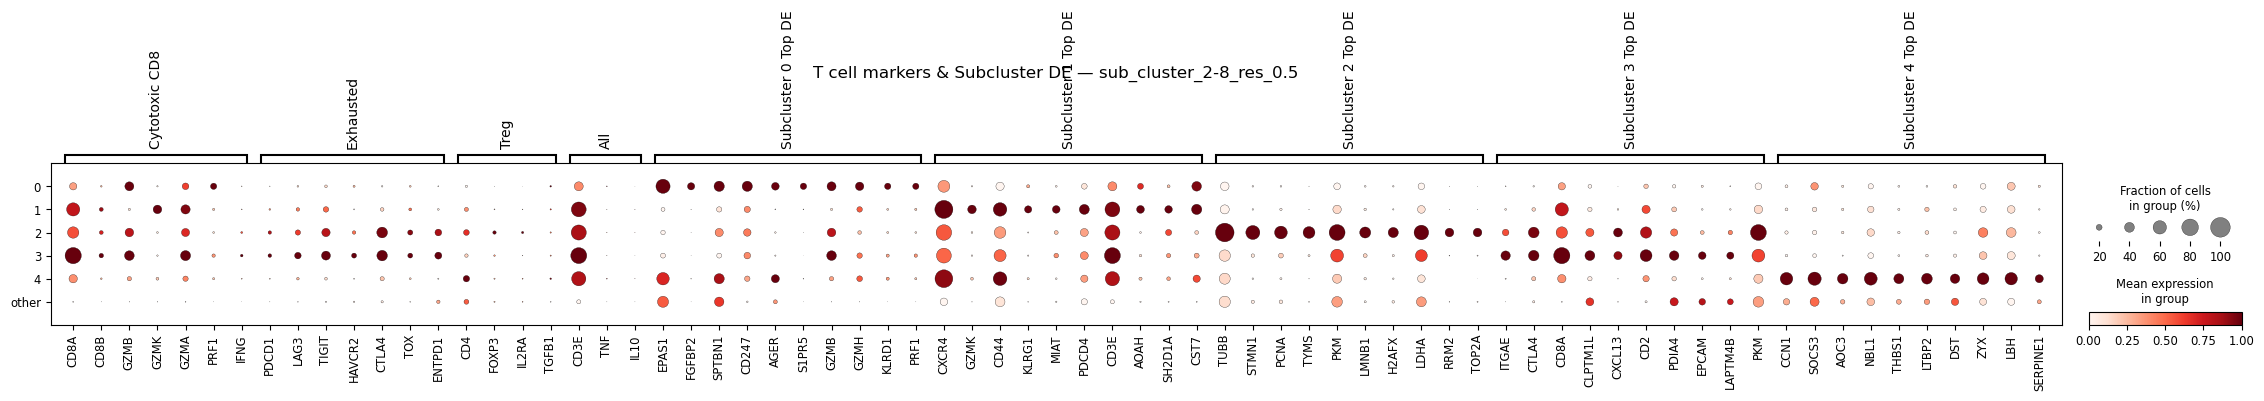


Sub-cluster sizes for sub_cluster_2-8_res_0.5:
sub_cluster_2-8_res_0.5
other    265989
1          4676
0          3028
3          2624
4          1067
2           944
Name: count, dtype: int64
Starting Sub Resolutions 0.37


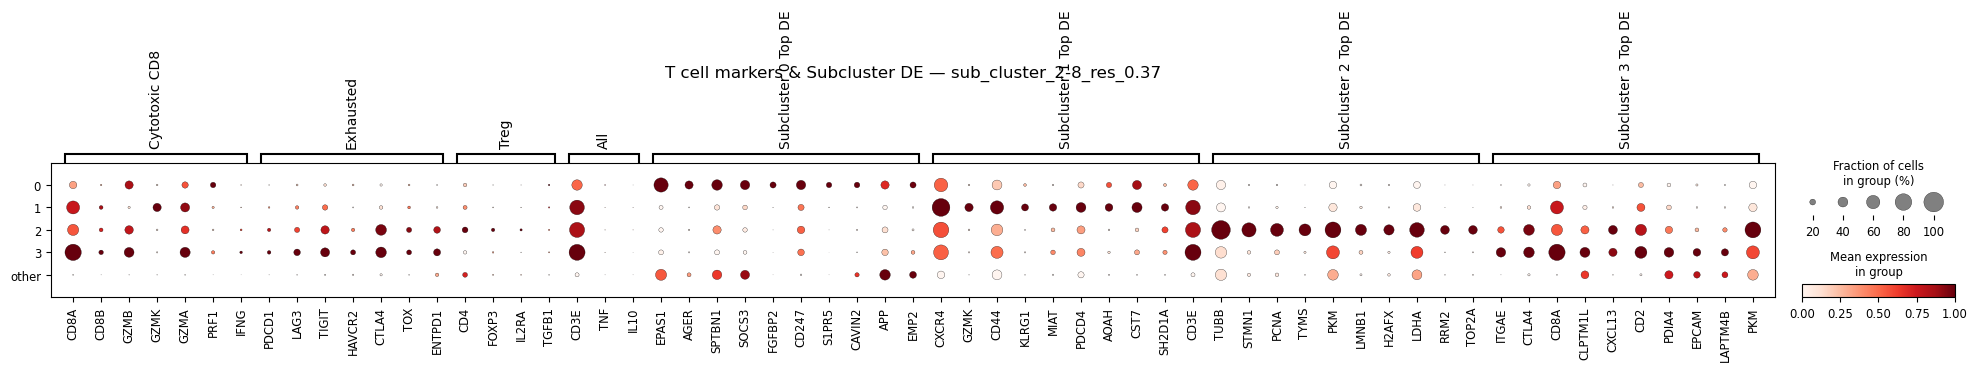


Sub-cluster sizes for sub_cluster_2-8_res_0.37:
sub_cluster_2-8_res_0.37
other    265989
1          4997
0          3818
3          2602
2           922
Name: count, dtype: int64
Starting Sub Resolutions 0.25


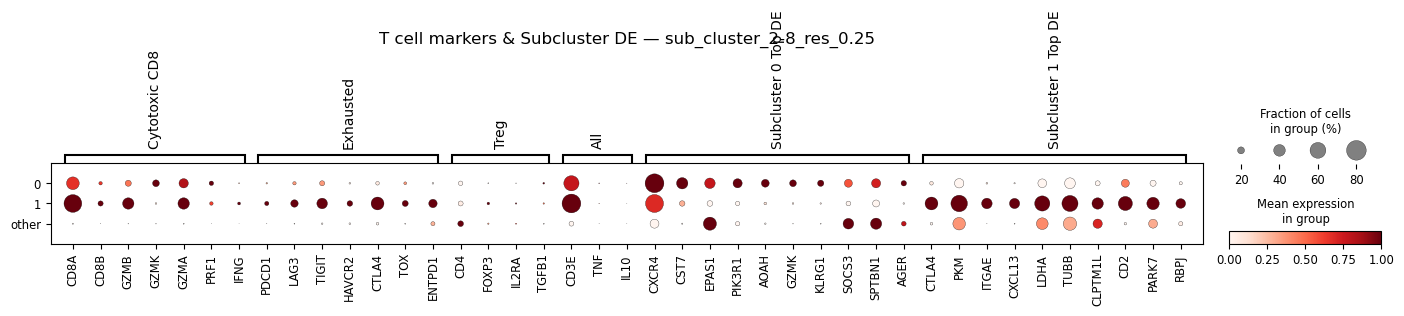


Sub-cluster sizes for sub_cluster_2-8_res_0.25:
sub_cluster_2-8_res_0.25
other    265989
0          8939
1          3400
Name: count, dtype: int64
Starting Sub Resolutions 0.15


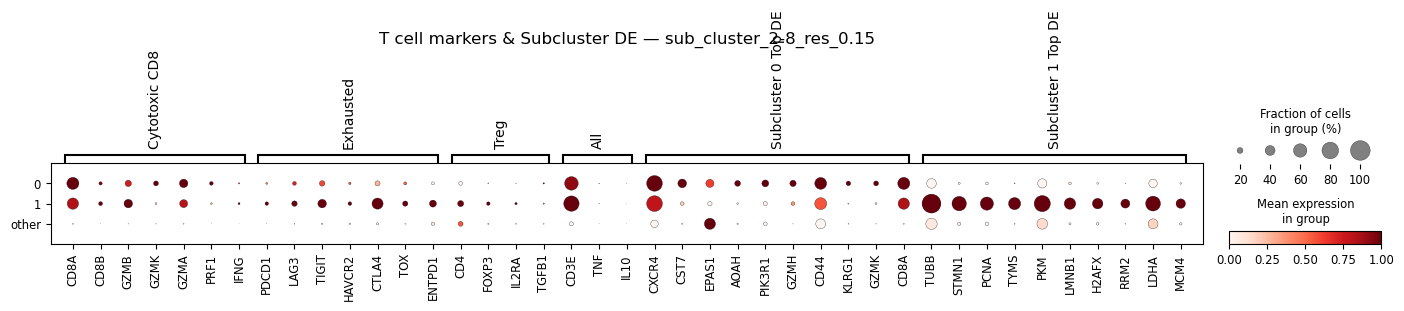


Sub-cluster sizes for sub_cluster_2-8_res_0.15:
sub_cluster_2-8_res_0.15
other    265989
0         11453
1           886
Name: count, dtype: int64
Starting Sub Resolutions 0.1


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (


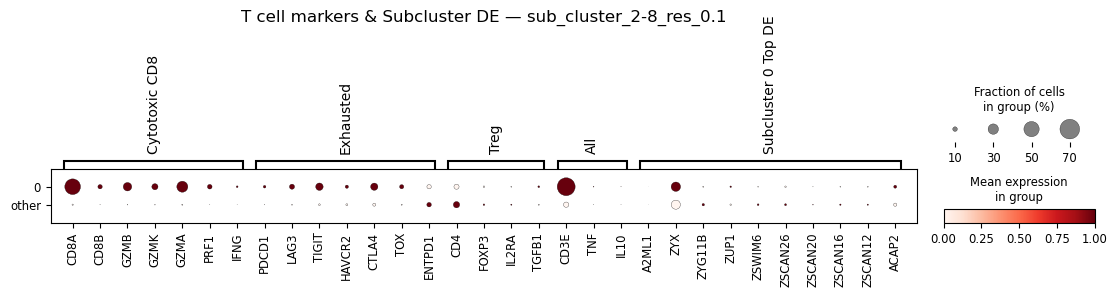


Sub-cluster sizes for sub_cluster_2-8_res_0.1:
sub_cluster_2-8_res_0.1
other    265989
0         12339
Name: count, dtype: int64
Starting Sub Resolutions 0.05


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (


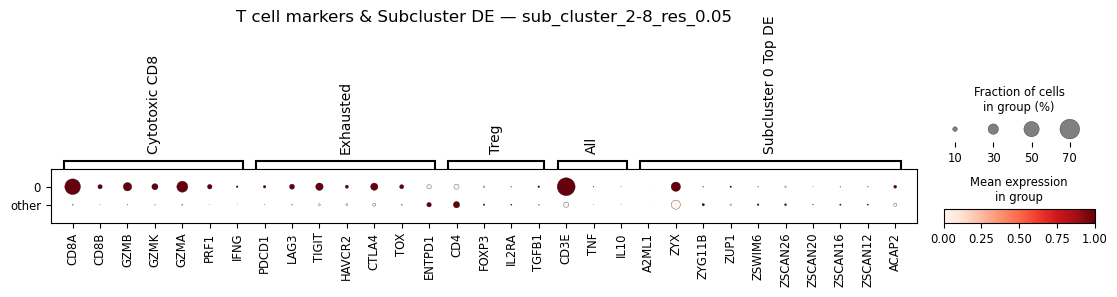


Sub-cluster sizes for sub_cluster_2-8_res_0.05:
sub_cluster_2-8_res_0.05
other    265989
0         12339
Name: count, dtype: int64


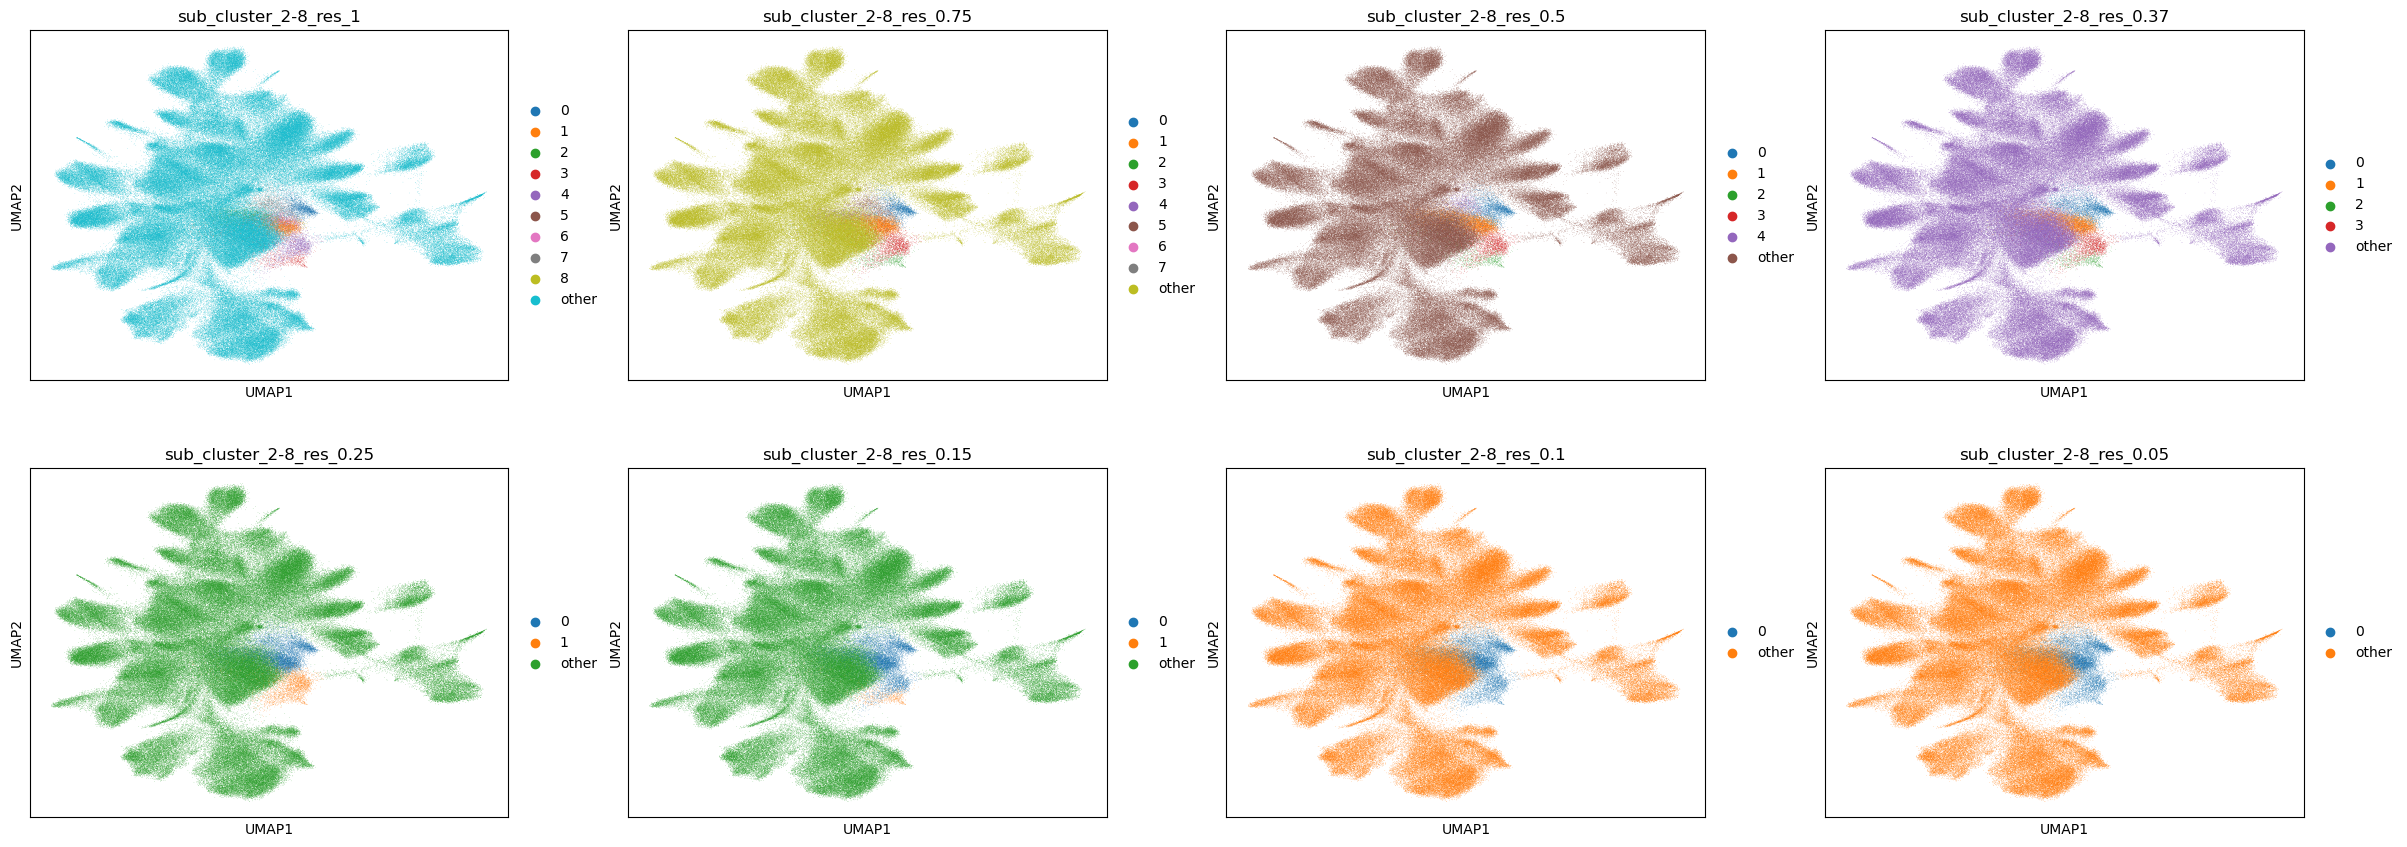

In [ ]:
print('starting cd8')
for sub_res in sub_resolutions:
    subcluster(adata, cd8, sub_res, clusters_res_label=res_label(res), de_genes_dict=de_genes_dict)
sc.pl.umap(adata, color=[sub_res_label(sub_res, cd8) for sub_res in sub_resolutions])

In [ ]:
# ============================================================
# Time to assign  -  fine T-cell annotations from collaborator's notes.
# "We only want T cells": a cell is kept as a T cell ONLY if it lands in a
# subcluster she explicitly annotated. Everything else -- the contaminated CD4
# cluster(s) and any un-annotated CD8/CD4 subcluster -- is contamination/noise
# and set to 'other' at ALL tiers (Tier1 is removed for noise, not just Tier3).
#
# IMPORTANT: the sub-resolutions below MUST match those used in the subcluster
# loop above (sub_resolutions). We build the column via sub_res_label() and
# assert it exists so a resolution mismatch fails loudly instead of mislabeling.
# ============================================================

# --- CD8 subcluster annotations ---
cd8_sub_res = 0.5
cd8_labels = {'0': 'Terminal effector CD8 T cell', '1': 'Effector CD8 T cell', '2': 'Proliferating CD8 T cell', '3': 'Trm CD8 T cell'}

# --- CD4 subcluster annotations ---  (None => CD4 is contamination)
cd4_sub_res = 0.75
cd4_labels = {'0': 'Treg'}

cd8_sub_col = sub_res_label(cd8_sub_res, cd8) if cd8_sub_res is not None else None
cd4_sub_col = sub_res_label(cd4_sub_res, cd4) if cd4_sub_res is not None else None
if cd8_sub_col is not None:
    assert cd8_sub_col in adata.obs, f"{cd8_sub_col} missing -- run the CD8 subcluster loop at res {cd8_sub_res}"
if cd4_sub_col is not None:
    assert cd4_sub_col in adata.obs, f"{cd4_sub_col} missing -- run the CD4 subcluster loop at res {cd4_sub_res}"

# Tier3: fine functional label, only for annotated subclusters
adata.obs['Tier3'] = 'other'
if cd8_sub_col is not None:
    for clust, label in cd8_labels.items():
        adata.obs.loc[adata.obs[cd8_sub_col] == clust, 'Tier3'] = label
if cd4_sub_col is not None:
    for clust, label in cd4_labels.items():
        adata.obs.loc[adata.obs[cd4_sub_col] == clust, 'Tier3'] = label
adata.obs['Tier3'] = adata.obs['Tier3'].astype('category')

# A cell is a real T cell iff it received a Tier3 label.
is_tcell = adata.obs['Tier3'] != 'other'

# Tier2: CD8- vs CD4-origin, only for confirmed T cells
adata.obs['Tier2'] = 'other'
if cd8_sub_col is not None:
    adata.obs.loc[is_tcell & adata.obs[cd8_sub_col].isin(list(cd8_labels)), 'Tier2'] = 'CD8 T Cell'
if cd4_sub_col is not None:
    adata.obs.loc[is_tcell & adata.obs[cd4_sub_col].isin(list(cd4_labels)), 'Tier2'] = 'CD4 T Cell'
adata.obs['Tier2'] = adata.obs['Tier2'].astype('category')

# Tier1: 'T Cell' ONLY where a fine label was assigned (noise/contamination dropped)
adata.obs['Tier1'] = np.where(is_tcell, 'T Cell', 'other')
adata.obs['Tier1'] = adata.obs['Tier1'].astype('category')

# Keep the exploratory boolean flags consistent with the cleaned annotation
adata.obs['t_cell'] = is_tcell
adata.obs['cd8'] = adata.obs['Tier2'] == 'CD8 T Cell'
adata.obs['cd4'] = adata.obs['Tier2'] == 'CD4 T Cell'

print("Tier1:\n", adata.obs['Tier1'].value_counts())
print("\nTier2:\n", adata.obs['Tier2'].value_counts())
print("\nTier3:\n", adata.obs['Tier3'].value_counts())


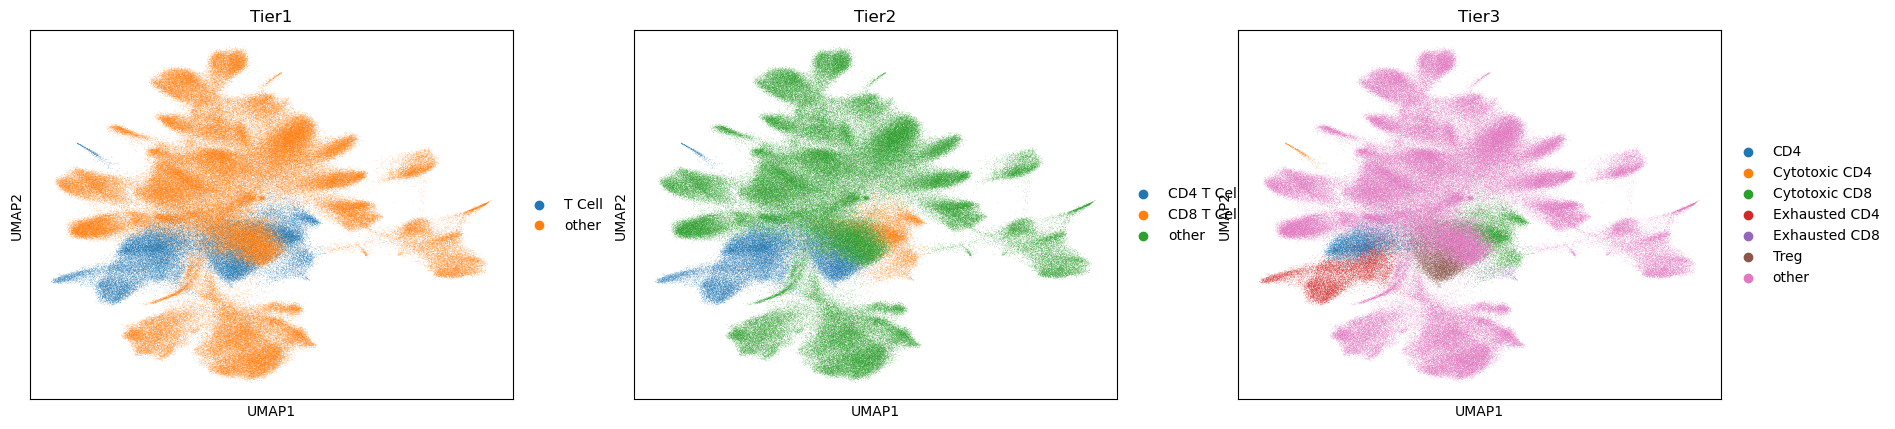

In [ ]:
sc.pl.umap(adata, color=['Tier1', 'Tier2', 'Tier3'])

In [ ]:
adata.write_h5ad(f'{DATA_DIR}/adata.h5ad')